## Energy System Modeling

## 01. Basic Energy System

In [1]:
# importing relevant packages
import pyomo.environ as pyo
import pandas as pd

In [2]:
# creating an abstract model
model = pyo.AbstractModel()

In [3]:
# creating the lists for the sets
technology = ['SolarPV', 'CoalMine', 'GasExtractor', 'CoalPowerPlant', 'GasPowerPlant', 'CoalCHPPlant', 'GasCHPPlant']
fuel = ['Power', 'Heat', 'Coal', 'Gas']

# creating the sets
model.Technology = pyo.Set(initialize = technology)
model.Fuel = pyo.Set(initialize = fuel)

In [4]:
# create a dictionary for the parameter variable cost
var_cost = {
    'SolarPV': 0.01, 
    'CoalPowerPlant': 1,
    'CoalCHPPlant': 1,
    'GasPowerPlant': 1,
    'GasCHPPlant': 0.3, 
    'GasExtractor': 0.2, 
    'CoalMine': 1
}

In [5]:
# create a dictionary for the parameter capital cost
cap_cost = {
    'SolarPV': 1, 
    'CoalPowerPlant': 1,
    'CoalCHPPlant': 0, 
    'GasPowerPlant': 1, 
    'GasCHPPlant': 0, 
    'GasExtractor': 1, 
    'CoalMine': 1
}

In [6]:
# create a dictionary for the parameter demand
demand = {
    'Power': 10,
    'Heat': 10
}

In [7]:
# import data for the parameters input and output ratio from csv file
readin_inputratio = pd.read_csv('inputratio.csv', index_col=[0,1], sep=';').squeeze('columns')
readin_outputratio = pd.read_csv('outputratio.csv', index_col=[0,1], sep=';').squeeze('columns')

display(readin_inputratio)
display(readin_outputratio)

Technology      Fuel
CoalPowerPlant  Coal    1
CoalCHPPlant    Coal    1
GasPowerPlant   Gas     1
GasCHPPlant     Gas     1
Name: OutputRatio, dtype: int64

Technology      Fuel 
SolarPV         Power    0.5
CoalPowerPlant  Power    1.0
CoalMine        Coal     1.0
CoalCHPPlant    Power    0.4
                Heat     0.6
GasPowerPlant   Power    1.0
GasExtractor    Gas      1.0
GasCHPPlant     Power    0.4
                Heat     0.6
Name: OutputRatio, dtype: float64

In [8]:
# create the parameter objects with the earlier created dictionaries/series
model.VariableCost = pyo.Param(model.Technology, default=0, initialize=var_cost)
model.CapitalCost = pyo.Param(model.Technology, default=0, initialize=cap_cost)
model.Demand = pyo.Param(model.Fuel, default =0, initialize=demand)
model.OutputRatio = pyo.Param(model.Technology, model.Fuel, default=0, initialize=readin_outputratio)
model.InputRatio = pyo.Param(model.Technology, model.Fuel, default=0 , initialize=readin_inputratio)

In [9]:
# create the variable objects
model.TotalCost = pyo.Var(model.Technology, domain=pyo.NonNegativeReals)
model.FuelProductionByTechnology = pyo.Var(model.Technology, model.Fuel, domain=pyo.NonNegativeReals)
model.Capacity = pyo.Var(model.Technology, domain=pyo.NonNegativeReals)
model.FuelUseByTechnology = pyo.Var(model.Technology, model.Fuel, domain=pyo.NonNegativeReals)

In [10]:
# create the objective function
def obj_function(model): 
    return pyo.summation(model.TotalCost)

# create the objective object with the earlier created objective function
model.obj = pyo.Objective(rule=obj_function)

In [11]:
# create the constraint functions
def demand_adequacy(model,f): 
    return sum(model.FuelProductionByTechnology[t,f] for t in model.Technology) >= model.Demand[f] + sum(model.FuelUseByTechnology[t,f] for t in model.Technology)

def productioncost(model,t): 
    return sum(model.FuelProductionByTechnology[t,f] for f in model.Fuel) * model.VariableCost[t] + model.Capacity[t] * model.CapitalCost[t] == model.TotalCost[t]

def productionfunction(model,t,f): 
    return model.OutputRatio[t,f] * model.Capacity[t] >= model.FuelProductionByTechnology[t,f]

def usefunction(model,t,f): 
    return model.InputRatio[t,f] * sum(model.FuelProductionByTechnology[t,ff] for ff in model.Fuel) == model.FuelUseByTechnology[t,f]

# create the constraint objects with the eaelier created constraint functions
model.DemandAdequacy = pyo.Constraint(model.Fuel, rule=demand_adequacy)
model.ProductionCost = pyo.Constraint(model.Technology, rule=productioncost)
model.ProductionFunction = pyo.Constraint(model.Technology, model.Fuel, rule=productionfunction)
model.UseFunction = pyo.Constraint(model.Technology, model.Fuel, rule=usefunction)

In [12]:
# create an instance of the model
instance = model.create_instance()

# create the solver object and specify the solver to be used
opt = pyo.SolverFactory('glpk')

# solve the model through the instance of the model
opt.solve(instance) 

{'Problem': [{'Name': 'unknown', 'Lower bound': 30.0, 'Upper bound': 30.0, 'Number of objectives': 1, 'Number of constraints': 68, 'Number of variables': 71, 'Number of nonzeros': 178, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': 0, 'Number of created subproblems': 0}}, 'Error rc': 0, 'Time': 0.06659412384033203}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

In [13]:
# display the results
instance.display()

Model unknown

  Variables:
    TotalCost : Size=7, Index=Technology
        Key            : Lower : Value : Upper : Fixed : Stale : Domain
          CoalCHPPlant :     0 :  -0.0 :  None : False : False : NonNegativeReals
              CoalMine :     0 :  -0.0 :  None : False : False : NonNegativeReals
        CoalPowerPlant :     0 :  -0.0 :  None : False : False : NonNegativeReals
           GasCHPPlant :     0 :   6.0 :  None : False : False : NonNegativeReals
          GasExtractor :     0 :  24.0 :  None : False : False : NonNegativeReals
         GasPowerPlant :     0 :  -0.0 :  None : False : False : NonNegativeReals
               SolarPV :     0 :  -0.0 :  None : False : False : NonNegativeReals
    FuelProductionByTechnology : Size=28, Index=FuelProductionByTechnology_index
        Key                         : Lower : Value : Upper : Fixed : Stale : Domain
           ('CoalCHPPlant', 'Coal') :     0 :   0.0 :  None : False : False : NonNegativeReals
            ('CoalCHPPla

In [14]:
# list of capacity values only retrievable by using a for loop
cap_list = []
for i in instance.Technology:
    cap_list.append(pyo.value(instance.Capacity[i]))

# creating a dictionary of technologies and their values  
cap_dict = {}    
for i in zip(instance.Technology, cap_list):
    cap_dict[i[0]] = i[1]

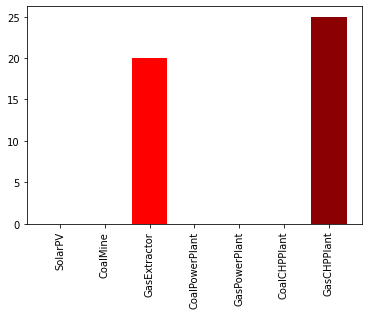

In [15]:
import matplotlib.pyplot as plt

# convert keys and values of the dictionary into lists and save them in variables
x = list(cap_dict.keys())
y = list(cap_dict.values())
colors = ['yellow', 'grey', 'red', 'brown', 'orange', 'saddlebrown', 'darkred']

plt.bar(x=x, height=y, color = colors)
plt.xticks(rotation=90)

plt.show()